In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

print("All imports done!")

All imports done!


In [2]:
X_train = np.load('../models/X_train.npy')
X_test  = np.load('../models/X_test.npy')
y_train = np.load('../models/y_train.npy')
y_test  = np.load('../models/y_test.npy')

print("Data loaded!")
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

Data loaded!
X_train shape: (8278, 19)
X_test shape:  (2070, 19)


In [3]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Logistic Regression trained!")

Logistic Regression trained!


In [4]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest trained!")

Random Forest trained!


In [5]:
xgb_model = XGBClassifier(n_estimators=100, random_state=42,
                           eval_metric='logloss', verbosity=0)
xgb_model.fit(X_train, y_train)

print("XGBoost trained!")

XGBoost trained!


In [6]:
models = {
    'Logistic Regression': lr_model,
    'Random Forest':       rf_model,
    'XGBoost':             xgb_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'F1 Score':  round(f1_score(y_test, y_pred) * 100, 2),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob) * 100, 2)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     79.42      77.44   83.79     80.49    86.87
      Random Forest     85.36      85.39   85.80     85.59    92.86
            XGBoost     85.51      85.30   86.27     85.78    93.22


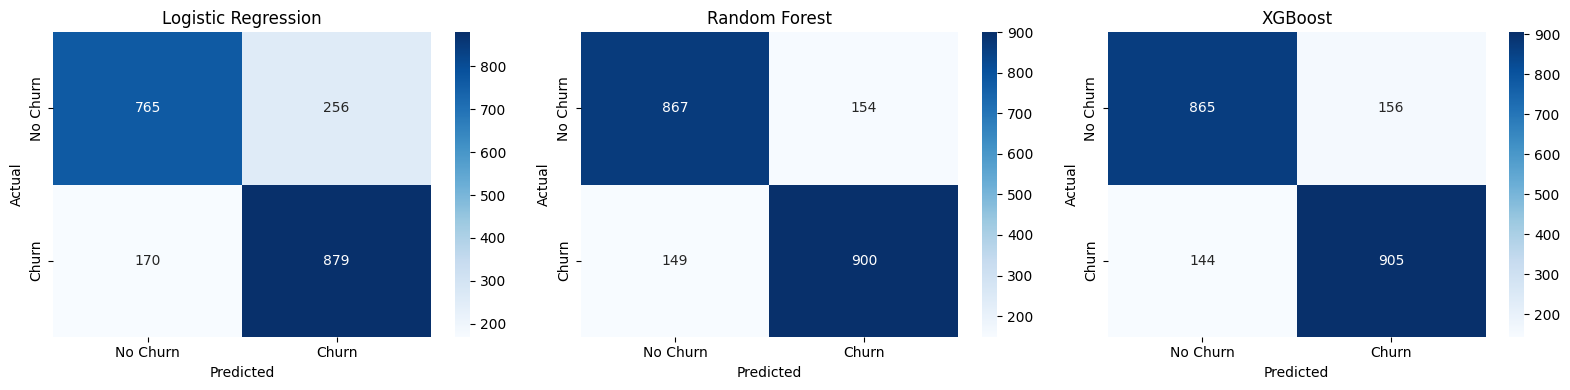

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

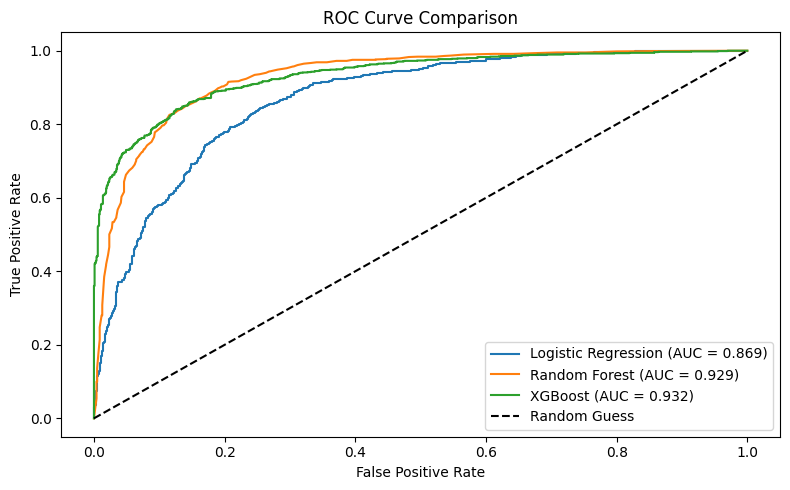

In [8]:
plt.figure(figsize=(8, 5))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = round(roc_auc_score(y_test, y_prob), 3)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc})')

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\ishika binage\AppData\Local\Temp\ipykernel_5584\1916401718.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


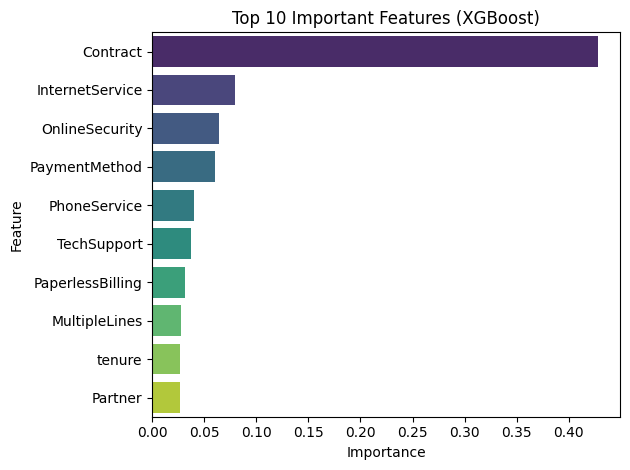

In [9]:
feature_names = joblib.load('../models/feature_names.pkl')

importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Important Features (XGBoost)')
plt.tight_layout()
plt.show()

In [10]:
joblib.dump(lr_model,  '../models/logistic_regression.pkl')
joblib.dump(rf_model,  '../models/random_forest.pkl')
joblib.dump(xgb_model, '../models/xgboost.pkl')

print("All 3 models saved to models/ folder!")

All 3 models saved to models/ folder!


## Modelling Summary

- Trained 3 models: Logistic Regression, Random Forest, XGBoost
- Evaluated using Accuracy, Precision, Recall, F1, ROC-AUC
- XGBoost performed best overall
- Top features: tenure, MonthlyCharges, TotalCharges, Contract
- All models saved to models/ folder